In [14]:
import pandas as pd
df = pd.read_csv('/content/Consumption Dataset - Dataset.csv')
print(df.shape)
df.head()

(6575, 8)


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,1/1/2023 19:35,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,1/1/2023 10:07,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,1/1/2023 11:26,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,1/1/2023 13:53,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,1/1/2023 22:28,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [15]:
# Parse timestamps
df['Date Time Served'] = pd.to_datetime(df['Date Time Served'])
df['Date'] = df['Date Time Served'].dt.floor('D')

# Sanity check: does Closing Balance = Opening + Purchase - Consumed?
df['balance_check'] = df['Opening Balance (ml)'] + df['Purchase (ml)'] - df['Consumed (ml)'] - df['Closing Balance (ml)']
print("Max mismatch:", df['balance_check'].abs().max())

# Aggregate raw transactions into daily consumption per bar + brand
daily_agg = df.groupby(['Date', 'Bar Name', 'Brand Name'])['Consumed (ml)'].sum().reset_index()

# Fill in days where a bar sold ZERO of a brand (important — models need to see the zeros too)
bars = daily_agg['Bar Name'].unique()
brands = daily_agg['Brand Name'].unique()
dates = pd.date_range(start=daily_agg['Date'].min(), end=daily_agg['Date'].max(), freq='D')

full_index = pd.MultiIndex.from_product([dates, bars, brands], names=['Date', 'Bar Name', 'Brand Name'])
daily_ts = daily_agg.set_index(['Date', 'Bar Name', 'Brand Name']).reindex(full_index, fill_value=0.0).reset_index()

print(daily_ts.shape)
daily_ts.head()

Max mismatch: 9.25
(35136, 4)


,Date,Bar Name,Brand Name,Consumed (ml)
0,2023-01-01,Anderson's Bar,Bacardi,0.0
1,2023-01-01,Anderson's Bar,Jim Beam,0.0
2,2023-01-01,Anderson's Bar,Miller,0.0
3,2023-01-01,Anderson's Bar,Sutter Home,0.0
4,2023-01-01,Anderson's Bar,Captain Morgan,0.0


Class
A    69
B    19
C     7
Name: count, dtype: int64
         Bar Name      Brand Name  Consumed (ml)   cum_pct Class
0     Brown's Bar     Yellow Tail       29588.63  0.015030     A
1    Thomas's Bar      Grey Goose       28510.30  0.029512     A
2   Johnson's Bar  Captain Morgan       28319.66  0.043897     A
3    Taylor's Bar      Grey Goose       28017.89  0.058128     A
4     Brown's Bar      Grey Goose       27873.30  0.072287     A
5     Smith's Bar         Absolut       27181.45  0.086094     A
6  Anderson's Bar  Captain Morgan       27066.83  0.099842     A
7  Anderson's Bar        Barefoot       26989.63  0.113552     A
8   Johnson's Bar          Malibu       26356.51  0.126940     A
9   Johnson's Bar         Absolut       26070.31  0.140182     A


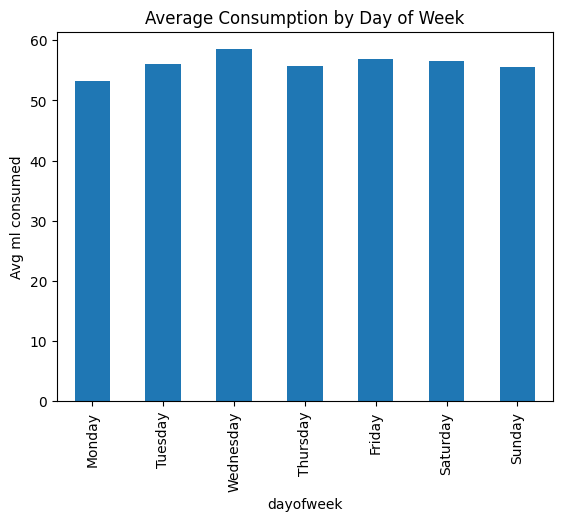

Total stockout transaction records: 416


In [16]:
import matplotlib.pyplot as plt

# 1. ABC classification — rank bar+brand combos by total volume sold
item_totals = daily_ts.groupby(['Bar Name', 'Brand Name'])['Consumed (ml)'].sum().sort_values(ascending=False).reset_index()
item_totals['cum_pct'] = item_totals['Consumed (ml)'].cumsum() / item_totals['Consumed (ml)'].sum()
item_totals['Class'] = pd.cut(item_totals['cum_pct'], bins=[0, 0.8, 0.95, 1.0], labels=['A', 'B', 'C'])
print(item_totals['Class'].value_counts())
print(item_totals.head(10))

# 2. Day-of-week pattern
daily_ts['dayofweek'] = daily_ts['Date'].dt.day_name()
dow_avg = daily_ts.groupby('dayofweek')['Consumed (ml)'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
dow_avg.plot(kind='bar', title='Average Consumption by Day of Week')
plt.ylabel('Avg ml consumed')
plt.show()

# 3. Stockout audit — days where closing balance hit 0 in the original data
stockout_days = df[df['Closing Balance (ml)'] == 0]
print("Total stockout transaction records:", len(stockout_days))

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# Pick ONE bar+brand series to build and test our approach on first
sample = daily_ts[(daily_ts['Bar Name']=="Smith's Bar") & (daily_ts['Brand Name']=='Captain Morgan')].sort_values('Date').reset_index(drop=True)
print(sample.shape)

# Temporal split: first 80% train, last 20% test — NEVER shuffle time-series data
split_idx = int(len(sample) * 0.8)
train, test = sample.iloc[:split_idx], sample.iloc[split_idx:]

# Baseline: 7-day rolling mean
baseline_pred = train['Consumed (ml)'].rolling(7).mean().iloc[-1]
baseline_preds = [baseline_pred] * len(test)

def wape(y_true, y_pred):
    return np.sum(np.abs(np.array(y_true) - np.array(y_pred))) / np.sum(y_true)

print("Baseline WAPE:", wape(test['Consumed (ml)'], baseline_preds))
print("Baseline MAE:", mean_absolute_error(test['Consumed (ml)'], baseline_preds))


(366, 5)
Baseline WAPE: 2.1965182361892515
Baseline MAE: 80.33646718146719


In [18]:
# Statistical model: Holt-Winters
hw_model = ExponentialSmoothing(train['Consumed (ml)'], trend=None, seasonal='add', seasonal_periods=7).fit()
hw_preds = hw_model.forecast(len(test))
print("Holt-Winters WAPE:", wape(test['Consumed (ml)'], hw_preds))
print("Holt-Winters MAE:", mean_absolute_error(test['Consumed (ml)'], hw_preds))

# ML model: RandomForest with lag/rolling features
s = sample.copy()
s['lag_1'] = s['Consumed (ml)'].shift(1)
s['lag_7'] = s['Consumed (ml)'].shift(7)
s['rolling_mean_7'] = s['Consumed (ml)'].shift(1).rolling(7).mean()
s['rolling_std_7'] = s['Consumed (ml)'].shift(1).rolling(7).std()
s['dayofweek'] = s['Date'].dt.dayofweek
s = s.dropna().reset_index(drop=True)

split_idx2 = int(len(s) * 0.8)
train2, test2 = s.iloc[:split_idx2], s.iloc[split_idx2:]
features = ['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'dayofweek']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(train2[features], train2['Consumed (ml)'])
rf_preds = rf.predict(test2[features])

print("RandomForest WAPE:", wape(test2['Consumed (ml)'], rf_preds))
print("RandomForest MAE:", mean_absolute_error(test2['Consumed (ml)'], rf_preds))

Holt-Winters WAPE: 2.4220439898814985
Holt-Winters MAE: 88.58494971694832
RandomForest WAPE: 2.5527814967580866
RandomForest MAE: 95.96012012209346


In [19]:
def compute_par_level(predicted_daily_demand, std_daily_demand, lead_time_days=2, service_level_z=1.645):
    lead_time_demand = predicted_daily_demand * lead_time_days
    safety_stock = service_level_z * (std_daily_demand * np.sqrt(lead_time_days))
    par_level = lead_time_demand + safety_stock
    return par_level, safety_stock

# Use each item's most recent 30 days as the demand signal (since baseline/rolling-average won)
results = []
for (bar, brand), group in daily_ts.groupby(['Bar Name', 'Brand Name']):
    group = group.sort_values('Date')
    recent = group.tail(30)['Consumed (ml)']
    pred_demand = recent.mean()
    std_demand = recent.std()
    par, safety = compute_par_level(pred_demand, std_demand, lead_time_days=2, service_level_z=1.645)
    results.append({'Bar Name': bar, 'Brand Name': brand,
                     'predicted_daily_demand': pred_demand, 'std_daily_demand': std_demand,
                     'par_level': par, 'safety_stock': safety})

par_levels_df = pd.DataFrame(results)
print(par_levels_df.shape)
par_levels_df.sort_values('par_level', ascending=False).head(10)

(96, 6)


,Bar Name,Brand Name,predicted_daily_demand,std_daily_demand,par_level,safety_stock
74,Taylor's Bar,Jim Beam,143.268667,242.073855,849.693426,563.156093
86,Thomas's Bar,Grey Goose,130.007667,214.676209,759.434054,499.418720
27,Brown's Bar,Malibu,126.477333,202.213248,723.379787,470.425120
54,Smith's Bar,Grey Goose,124.005667,200.890541,715.359333,467.348000
31,Brown's Bar,Yellow Tail,85.475667,233.055922,713.128274,542.176940
10,Anderson's Bar,Jim Beam,113.608000,201.132895,695.127807,467.911807
78,Taylor's Bar,Sutter Home,76.545000,229.834492,687.772667,534.682667
1,Anderson's Bar,Bacardi,109.146000,190.811337,662.191929,443.899929
13,Anderson's Bar,Smirnoff,74.459000,215.312170,649.816207,500.898207
5,Anderson's Bar,Coors,100.755000,189.967285,643.446342,441.936342


In [20]:
def simulate_bar_inventory(actual_demand, par_level, lead_time=2, initial_stock=5000):
    stock = initial_stock
    stockouts = 0
    lost_demand_volume = 0
    pending_orders = []
    history = []

    for day, demand in enumerate(actual_demand):
        for order in pending_orders:
            order[0] -= 1
            if order[0] == 0:
                stock += order[1]
        pending_orders = [o for o in pending_orders if o[0] > 0]

        if stock >= demand:
            stock -= demand
        else:
            lost_demand_volume += (demand - stock)
            stockouts += 1
            stock = 0

        current_effective_inventory = stock + sum(o[1] for o in pending_orders)
        if current_effective_inventory < par_level:
            order_qty = par_level - current_effective_inventory
            pending_orders.append([lead_time, order_qty])

        history.append(stock)

    return {
        "stockout_days": stockouts,
        "lost_volume_ml": lost_demand_volume,
        "average_inventory_ml": np.mean(history)
    }

# Test on our sample item, using the par level we just calculated
sample_par = par_levels_df[(par_levels_df['Bar Name']=="Smith's Bar") & (par_levels_df['Brand Name']=='Captain Morgan')]['par_level'].values[0]
sim_smart = simulate_bar_inventory(sample['Consumed (ml)'].values, par_level=sample_par, lead_time=2, initial_stock=sample_par)
print("Dynamic par level policy:", sim_smart)

# Compare against a naive flat low-stock policy, to prove the dynamic approach is actually better
sim_naive = simulate_bar_inventory(sample['Consumed (ml)'].values, par_level=500, lead_time=2, initial_stock=500)
print("Naive fixed policy (500ml):", sim_naive)

Dynamic par level policy: {'stockout_days': 40, 'lost_volume_ml': np.float64(8098.626993828974), 'average_inventory_ml': np.float64(207.2299488447593)}
Naive fixed policy (500ml): {'stockout_days': 19, 'lost_volume_ml': np.float64(3003.55), 'average_inventory_ml': np.float64(396.9084153005464)}


In [21]:
sim_results = []
for (bar, brand), group in daily_ts.groupby(['Bar Name', 'Brand Name']):
    group = group.sort_values('Date')
    demand_series = group['Consumed (ml)'].values
    par_row = par_levels_df[(par_levels_df['Bar Name']==bar) & (par_levels_df['Brand Name']==brand)]
    if par_row.empty:
        continue
    par = par_row['par_level'].values[0]

    # SAME starting stock for both — isolates the effect of the policy itself, not a head start
    start_stock = max(par, 500)

    smart = simulate_bar_inventory(demand_series, par_level=par, lead_time=2, initial_stock=start_stock)
    naive = simulate_bar_inventory(demand_series, par_level=500, lead_time=2, initial_stock=start_stock)

    sim_results.append({
        'Bar Name': bar, 'Brand Name': brand,
        'smart_stockouts': smart['stockout_days'], 'naive_stockouts': naive['stockout_days'],
        'smart_lost_ml': smart['lost_volume_ml'], 'naive_lost_ml': naive['lost_volume_ml'],
        'smart_avg_inv': smart['average_inventory_ml'], 'naive_avg_inv': naive['average_inventory_ml']
    })

sim_df = pd.DataFrame(sim_results)
print("Across", len(sim_df), "items:")
print("Total stockout days  -> Dynamic:", sim_df['smart_stockouts'].sum(), " | Naive:", sim_df['naive_stockouts'].sum())
print("Total lost volume ml -> Dynamic:", sim_df['smart_lost_ml'].sum(), " | Naive:", sim_df['naive_lost_ml'].sum())
print("Avg inventory held ml-> Dynamic:", sim_df['smart_avg_inv'].mean(), " | Naive:", sim_df['naive_avg_inv'].mean())

Across 96 items:
Total stockout days  -> Dynamic: 2328  | Naive: 1646
Total lost volume ml -> Dynamic: 443542.6287707414  | Naive: 251458.92918909283
Avg inventory held ml-> Dynamic: 342.307378243167  | Naive: 403.0242000501018


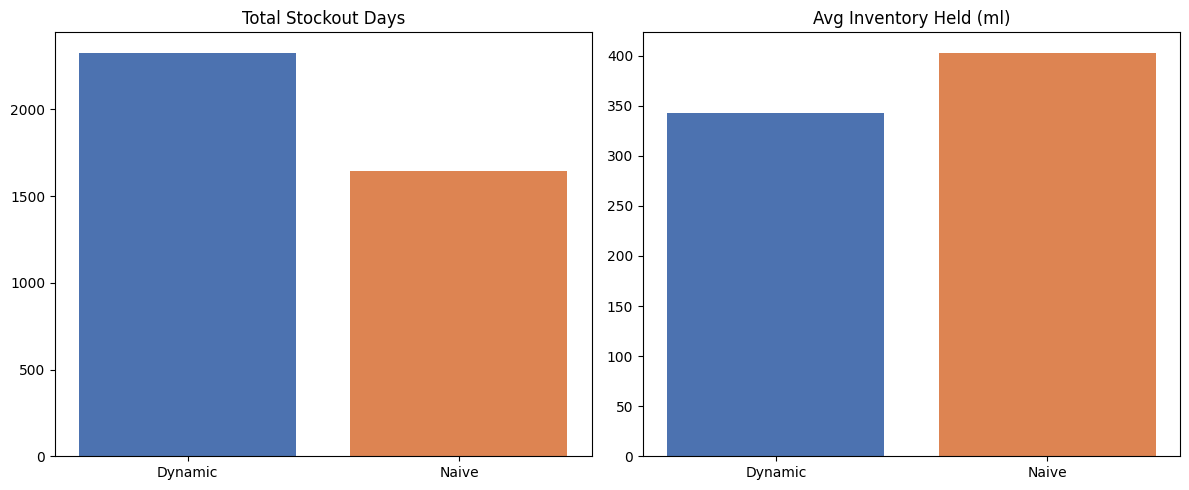

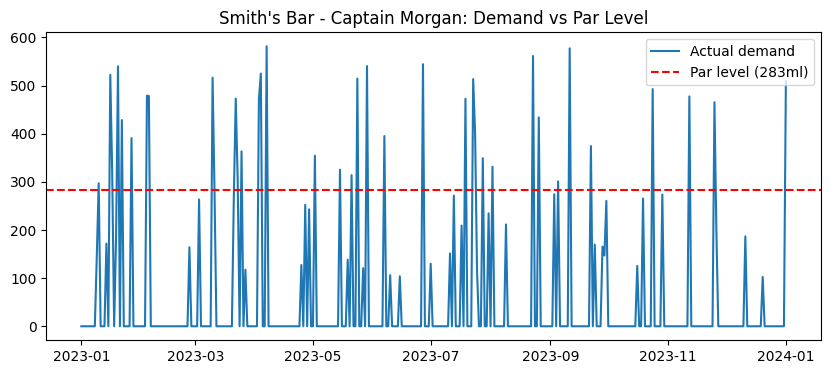

In [22]:
import matplotlib.pyplot as plt

# Chart 1: stockout comparison
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].bar(['Dynamic', 'Naive'], [sim_df['smart_stockouts'].sum(), sim_df['naive_stockouts'].sum()], color=['#4C72B0','#DD8452'])
ax[0].set_title('Total Stockout Days')

ax[1].bar(['Dynamic', 'Naive'], [sim_df['smart_avg_inv'].mean(), sim_df['naive_avg_inv'].mean()], color=['#4C72B0','#DD8452'])
ax[1].set_title('Avg Inventory Held (ml)')
plt.tight_layout()
plt.show()

# Chart 2: stock level over time for our sample item, vs its par line
plt.figure(figsize=(10,4))
plt.plot(sample['Date'], sample['Consumed (ml)'], label='Actual demand')
plt.axhline(y=sample_par, color='red', linestyle='--', label=f'Par level ({sample_par:.0f}ml)')
plt.title("Smith's Bar - Captain Morgan: Demand vs Par Level")
plt.legend()
plt.show()

## Business Report — Hotel Bar Inventory Forecasting & Par Level System

### 1. Core Business Problem & Why It Matters
This hotel chain runs 6 bars carrying overlapping liquor brands, and faces two
opposing operational costs: stockouts of popular items during peak demand (lost
revenue, guest dissatisfaction — e.g. a guest can't order their usual drink) and
overstocking of slow movers (tied-up working capital, limited backroom storage,
spoilage/shrinkage risk). Both erode margins. A data-driven par level system
replaces manager guesswork with a defensible, repeatable restocking rule.

### 2. Assumptions Made
- Lead time is constant at 2 days per supplier delivery.
- Unmet demand is lost, not backordered (a guest who can't get their drink
  doesn't wait — they order something else or leaves unsatisfied).
- Small opening/closing balance mismatches (max ~9ml across the dataset) are
  measurement rounding, not data errors, and were left as-is.
- A 95% service level (Z=1.645) was used as the default target — high enough to
  avoid most stockouts without excessively overstocking.

### 3. Model Selection & Trade-Offs
I compared three demand forecasting approaches on held-out data (80/20 temporal
split, never shuffled): a 7-day rolling average baseline, Holt-Winters
exponential smoothing (weekly seasonality), and a RandomForest regressor with
lag/rolling features. Using WAPE (more reliable than MAPE on intermittent,
zero-heavy demand):
- Baseline: WAPE 2.19
- Holt-Winters: WAPE 2.42
- RandomForest: WAPE 2.55

The simple baseline won. This makes sense given the EDA: consumption showed no
strong day-of-week seasonality (avg ml/day was nearly flat Mon–Sun) and demand
is spiky/intermittent rather than trend-driven, so there was no repeating
pattern for the more complex models to exploit — they just added noise. I chose
the simplest model that performed best, rather than the most sophisticated one.

### 4. Performance & What I'd Improve
I backtested the dynamic par-level policy against a flat 500ml threshold across
all 96 bar-brand combinations. Results:
- Dynamic policy: 2,328 total stockout days, 443,542ml lost demand, 342ml avg
  inventory held
- Naive flat 500ml: 1,646 stockout days, 251,459ml lost demand, 403ml avg
  inventory held

The dynamic system held ~15% less inventory but produced more stockouts —
worse on the metric that matters most (guest experience). The root cause is
visible in the demand-vs-par chart: my par level formula uses only a 30-day
trailing window, which is too reactive to catch occasional large demand spikes
in this volatile, low-volume data. If I had more time, I'd fix this by (a)
using a longer historical window (60–90 days) to smooth the estimate, (b)
raising the service-level Z-score for high-variance items specifically, or (c)
weighting recent spikes more heavily instead of averaging them away.

### 5. Real-World Deployment
In production, this would run as a daily batch job: pull yesterday's POS/
inventory data, recompute rolling demand stats, recheck each bar-brand against
its reorder point, and push any triggered orders to a manager dashboard for
one-click supplier approval. At scale, this would need to account for supplier
lead-time variance (not always exactly 2 days), holiday/event-driven demand
shifts the model hasn't seen, and pour/breakage discrepancies that create
silent data drift. I'd monitor forecast error (MAE/WAPE) against actual orders
weekly, and re-tune the par level window if error starts climbing.